In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors #pip install scikit-learn
from sklearn.decomposition import PCA
from kneed import KneeLocator as kl

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')
print("Reading data...")
adata = sc.read_h5ad("../Data/Final.h5ad")
adata

Reading data...


AnnData object with n_obs × n_vars = 92942 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts'

In [3]:
# annotate mitochondrial genes as 'mt' and calculate qc metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [8]:
QC_data = adata.copy()
#basic filtering
sc.pp.filter_cells(QC_data, min_genes=200)
sc.pp.filter_genes(QC_data, min_cells=3)

# actually do the filtering by slicing the AnnData object
QC_data = QC_data[QC_data.obs.n_genes_by_counts < 2200, :]
QC_data = QC_data[QC_data.obs.pct_counts_mt < 5, :]
QC_data

View of AnnData object with n_obs × n_vars = 8738 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells'

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


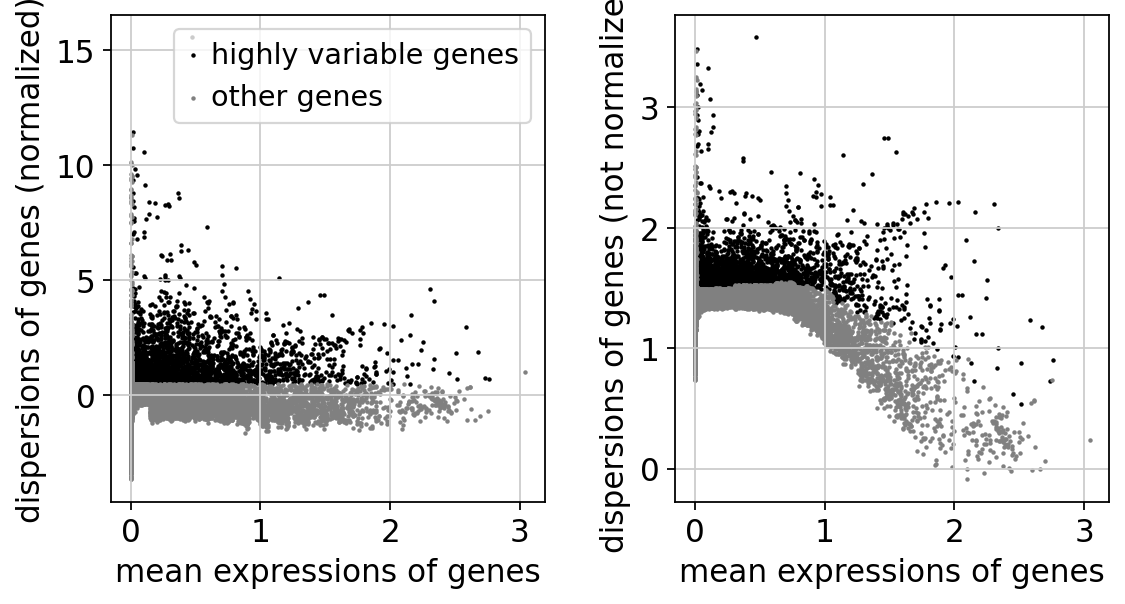

AnnData object with n_obs × n_vars = 8738 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [9]:
norm_data = QC_data.copy()
# normalize counts to 10,000 reads per cell..
sc.pp.normalize_total(norm_data, target_sum=1e4)

#log n+1 transform
sc.pp.log1p(norm_data)

# identify highly variable genes
sc.pp.highly_variable_genes(norm_data, min_mean=0.0125, max_mean=3, min_disp=0.5)

#plot dispersion vs expression
sc.pl.highly_variable_genes(norm_data)
norm_data

In [10]:
HVG_data = norm_data.copy()
#filter to only include HVGs
HVG_data.raw = HVG_data # freeze state of HVG_data by saving as raw attribute
HVG_data = HVG_data[:, HVG_data.var.highly_variable]
HVG_data

View of AnnData object with n_obs × n_vars = 8738 × 2725
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [11]:
pcHVG_data = HVG_data.copy()
#scale to unit variance for PCA, clip values exceding var 10
sc.pp.scale(pcHVG_data, max_value=10)

# reduce the dimensionality of the data using PCA
sc.tl.pca(pcHVG_data, svd_solver='arpack')

#save the result
pcHVG_data.write("../Data/pcHVG_data.h5ad")
#print
pcHVG_data

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:09)


AnnData object with n_obs × n_vars = 8738 × 2725
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

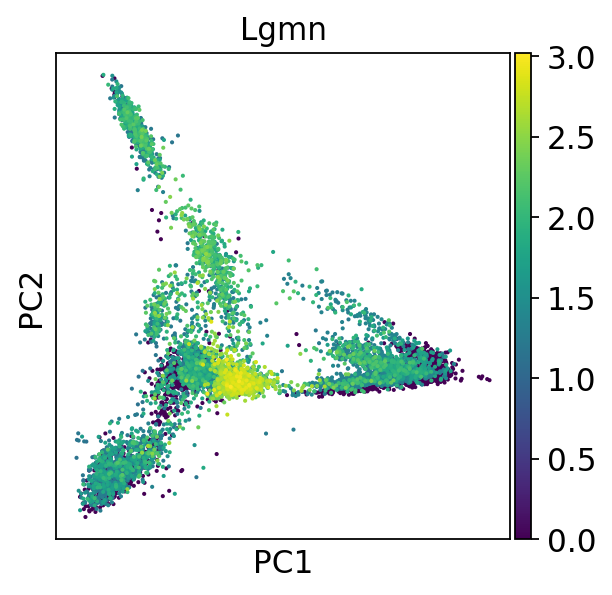

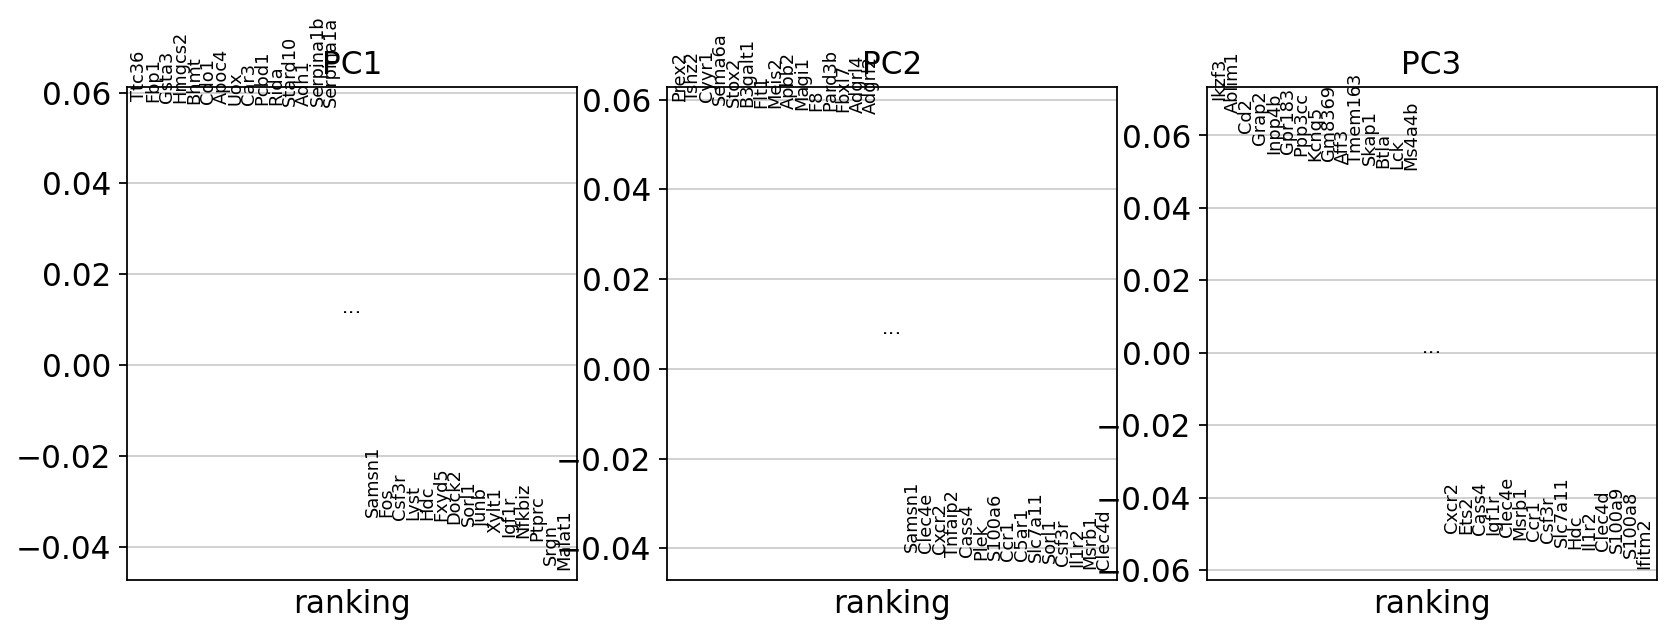

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:09)


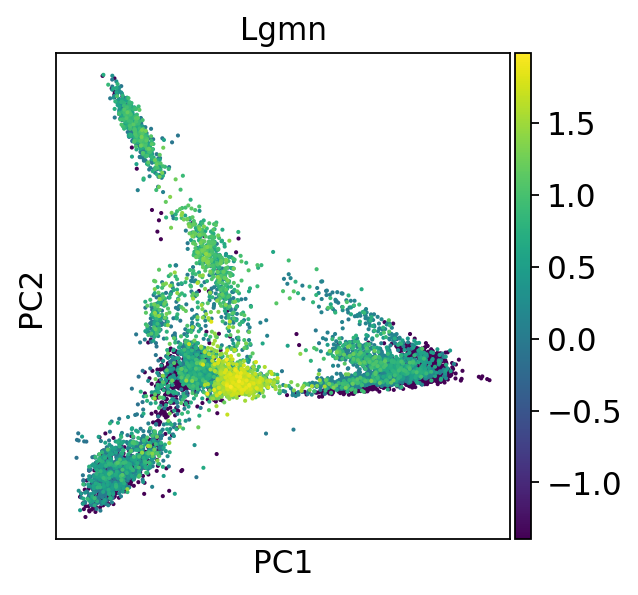

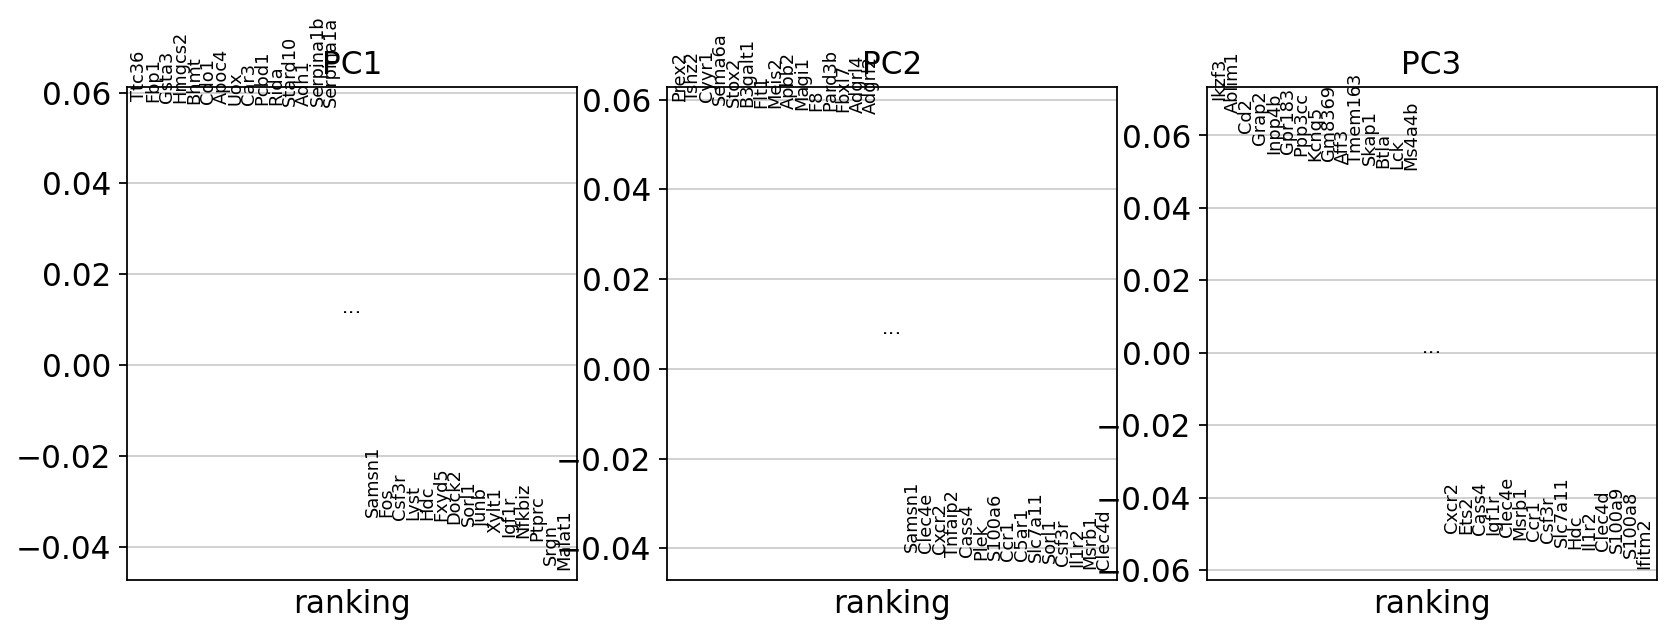

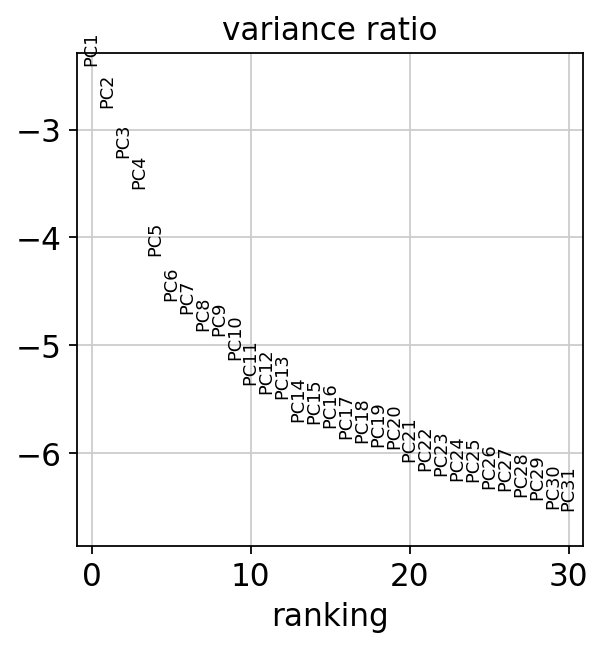

In [15]:
#scatter in the PCA coordinates of HVGs, won't be used later on, only for vis
sc.pl.pca(pcHVG_data, color='Lgmn')

#plot the loadings, or the contribution of each gene to the PCs
sc.pl.pca_loadings(pcHVG_data)

#scatter in the PCA coordinates of all genes
sc.pp.scale(norm_data, max_value=10)
sc.tl.pca(norm_data, svd_solver='arpack')
sc.pl.pca(norm_data, color='Lgmn')
sc.pl.pca_loadings(norm_data)

#image you have two samples, and you want to check how similar the PCs are
#how can we quantify the similarity of gene contributions to PCs?

#how many PCs should we use to cluster?
# visualize scree plot
sc.pl.pca_variance_ratio(pcHVG_data, log=True)

In [16]:
#define new function that finds the elbow dimension of the scree plot
def PCA_Elbow_fit(data):
    model = PCA().fit(data)
    explained_variance = model.explained_variance_ratio_
    pcs = list(range(1,explained_variance.shape[0]+1))#enumerate(explained_variance,1)
    klm = kl(pcs, explained_variance, S=1.0, curve='convex', direction='decreasing')
    pcs_used = klm.knee
    pc_list = list(range(1,pcs_used+1))
    new_data = PCA(n_components= pcs_used,svd_solver= "arpack").fit_transform(data)
    return pcs_used, new_data, pcs, explained_variance,pc_list

#extract cell x gene data from scanpy annData and create new pandas dataframe
label = "HVG_data"
new_frame = pd.DataFrame(HVG_data.X.toarray(), index=HVG_data.obs_names, columns=HVG_data.var_names)
pandas_data=new_frame.values
#new_frame.to_csv(output_path)

#execute PCA elbow fitting function
dim,new_matrix,pc_ax,pc_ay,col_labels=PCA_Elbow_fit(pandas_data)
print(dim)

23


           PC_1       PC_2       PC_3      PC_4      PC_5      PC_6      PC_7  \
163   -7.196661  -1.883011  -7.864232 -7.344817  8.136936 -5.391222 -6.815162   
487  -12.192001   1.282427   6.215900 -3.817288 -1.275515 -0.493310 -3.359668   
821   -6.882025  -2.218859  -7.775772 -6.822125  8.042181 -5.153142 -5.095062   
1069 -16.040088  11.740538  11.355647 -1.148515  0.724571 -0.033287 -0.504135   
1568  -4.116950  -2.875163  -8.855494 -7.269757  8.077277 -6.362231 -6.902170   

          PC_8      PC_9     PC_10  ...     PC_14     PC_15     PC_16  \
163   0.298147 -0.643190  7.594456  ... -0.641941 -0.104535 -1.825969   
487   0.785628 -0.251386  2.256909  ...  1.471877 -6.845661  7.733246   
821   0.879901 -0.161061  6.966088  ... -0.341742  0.266107 -1.758875   
1069 -4.345897 -1.921564  0.931371  ... -2.479604 -0.905504  1.136697   
1568 -2.298156 -2.076188  8.154560  ... -0.028803  1.425680 -0.883272   

         PC_17     PC_18     PC_19     PC_20     PC_21     PC_22     PC_23

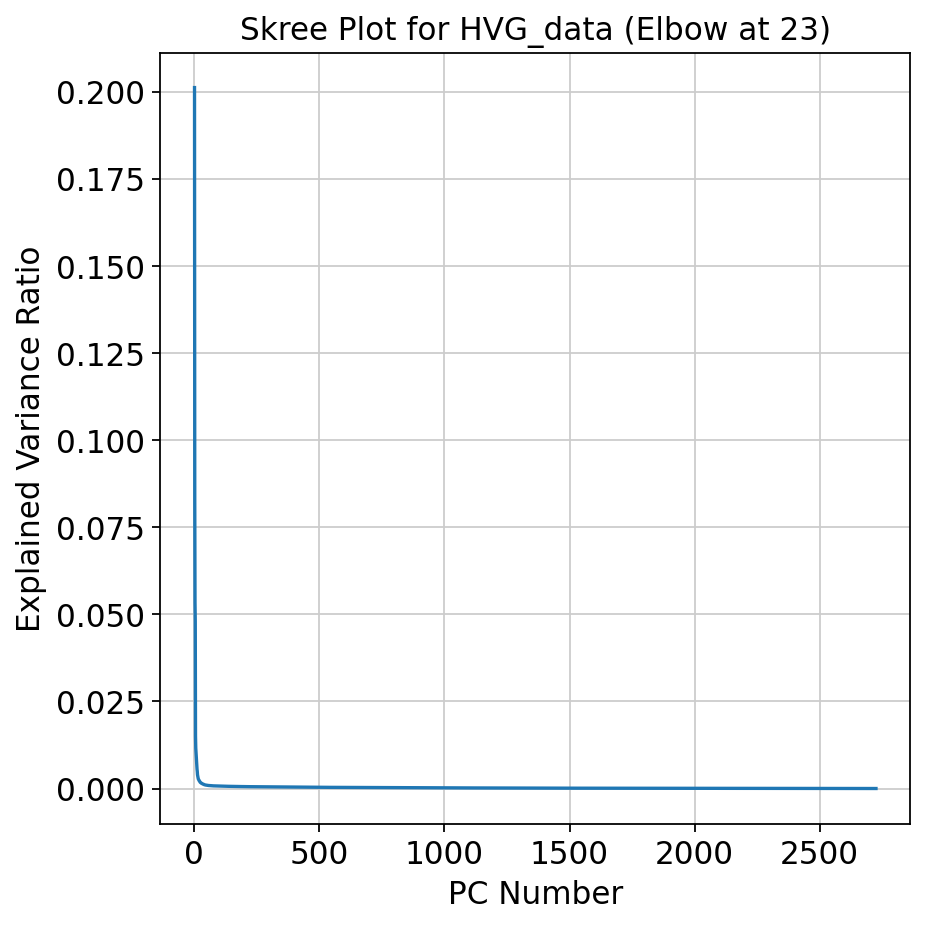

In [17]:
#create new data frame of cells x PC values
columns=["PC_"+str(i) for i in col_labels]
output_path = "../ProcessedData/PCA_"+ label + str(dim)+ ".csv"
PC_frame= pd.DataFrame(new_matrix, index= new_frame.index.values.tolist(), columns = columns)
print(PC_frame.head())
print(PC_frame.shape)
PC_frame.to_csv(output_path)

fig= plt.figure(figsize = (6,6))
ax1 = fig.add_subplot(111)
ax1.set_title("Skree Plot for "+label+" (Elbow at "+str(dim)+")")
ax1.plot(pc_ax, pc_ay)
ax1.set_xlabel("PC Number")
ax1.set_ylabel("Explained Variance Ratio")
fig.tight_layout()
plt.savefig("../ProcessedData/PCA_"+str(dim)+".png")

In [18]:
#back to scanpy
#computing the neighborhood graph
sc.pp.neighbors(pcHVG_data, n_neighbors=10, n_pcs=dim)

#visualizing data with umap
sc.tl.umap(pcHVG_data)

computing neighbors
    using 'X_pca' with n_pcs = 23
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:19)


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


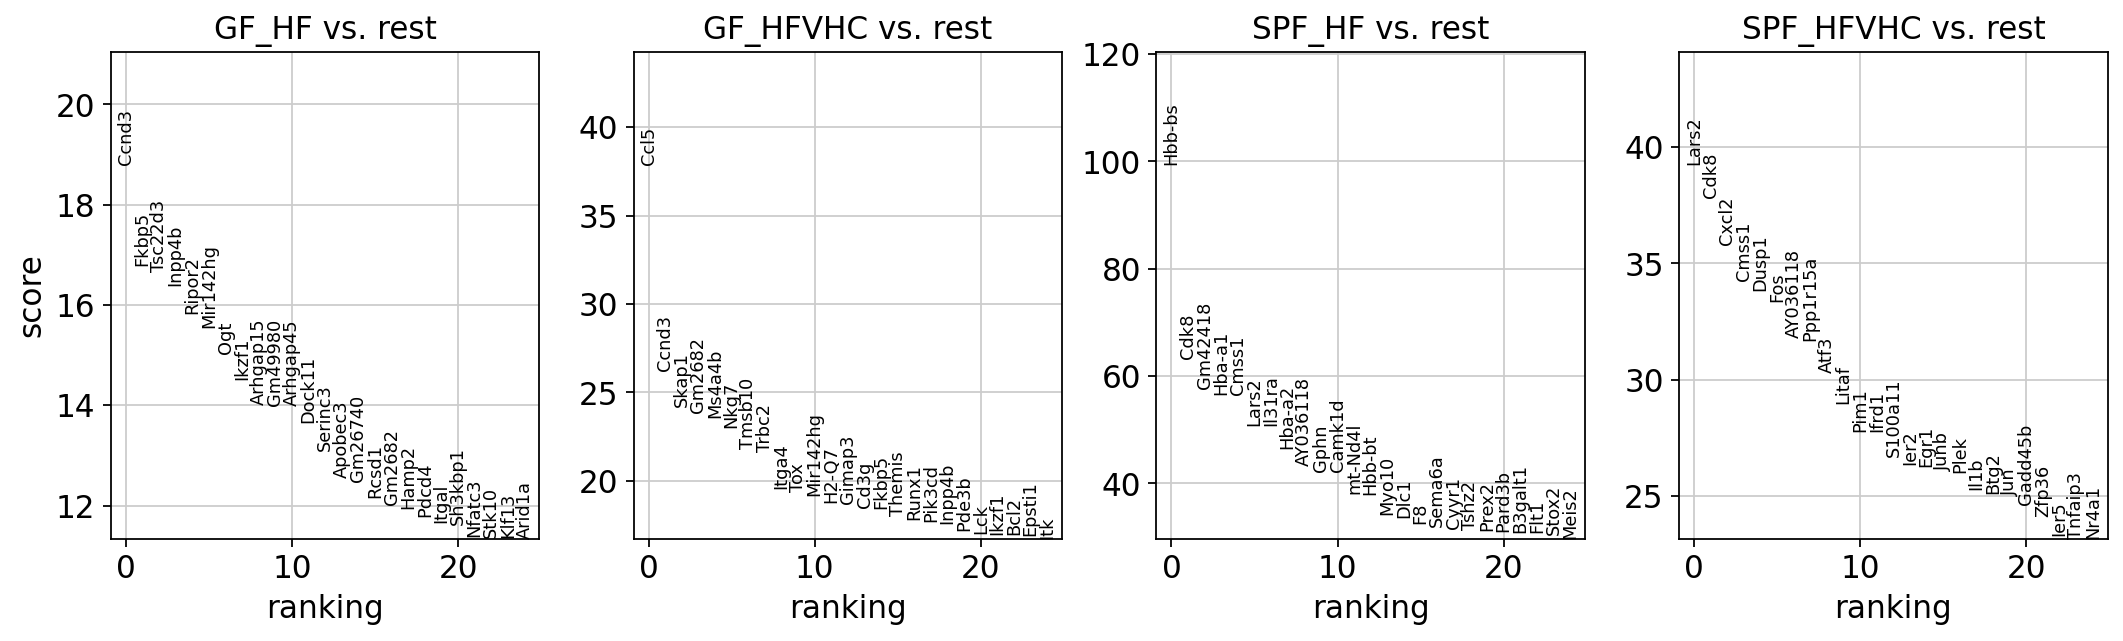

In [20]:
sc.tl.rank_genes_groups(pcHVG_data, 'group', method='t-test') # or 'wilcoxon', 'logreg', etc.

# View the results
sc.pl.rank_genes_groups(pcHVG_data, n_genes=25, sharey=False) # shows top 25 genes per cluster

# Access the results programmatically
results = pcHVG_data.uns['rank_genes_groups']

In [23]:
names

rec.array([('Ccnd3', 'Ccl5', 'Hbb-bs', 'Lars2'),
           ('Fkbp5', 'Ccnd3', 'Cdk8', 'Cdk8'),
           ('Tsc22d3', 'Skap1', 'Gm42418', 'Cxcl2'), ...,
           ('Gm42418', 'Cdk8', 'Ccl5', 'Hba-a1'),
           ('Hba-a1', 'Hba-a1', 'Lsp1', 'Hba-a2'),
           ('Hbb-bs', 'Hbb-bs', 'Mir142hg', 'Hbb-bs')],
          dtype=[('GF_HF', 'O'), ('GF_HFVHC', 'O'), ('SPF_HF', 'O'), ('SPF_HFVHC', 'O')])

In [26]:
results = pcHVG_data.uns['rank_genes_groups']
names = results['names']
scores = results['scores']
print(names)

[('Ccnd3', 'Ccl5', 'Hbb-bs', 'Lars2') ('Fkbp5', 'Ccnd3', 'Cdk8', 'Cdk8')
 ('Tsc22d3', 'Skap1', 'Gm42418', 'Cxcl2') ...
 ('Gm42418', 'Cdk8', 'Ccl5', 'Hba-a1')
 ('Hba-a1', 'Hba-a1', 'Lsp1', 'Hba-a2')
 ('Hbb-bs', 'Hbb-bs', 'Mir142hg', 'Hbb-bs')]


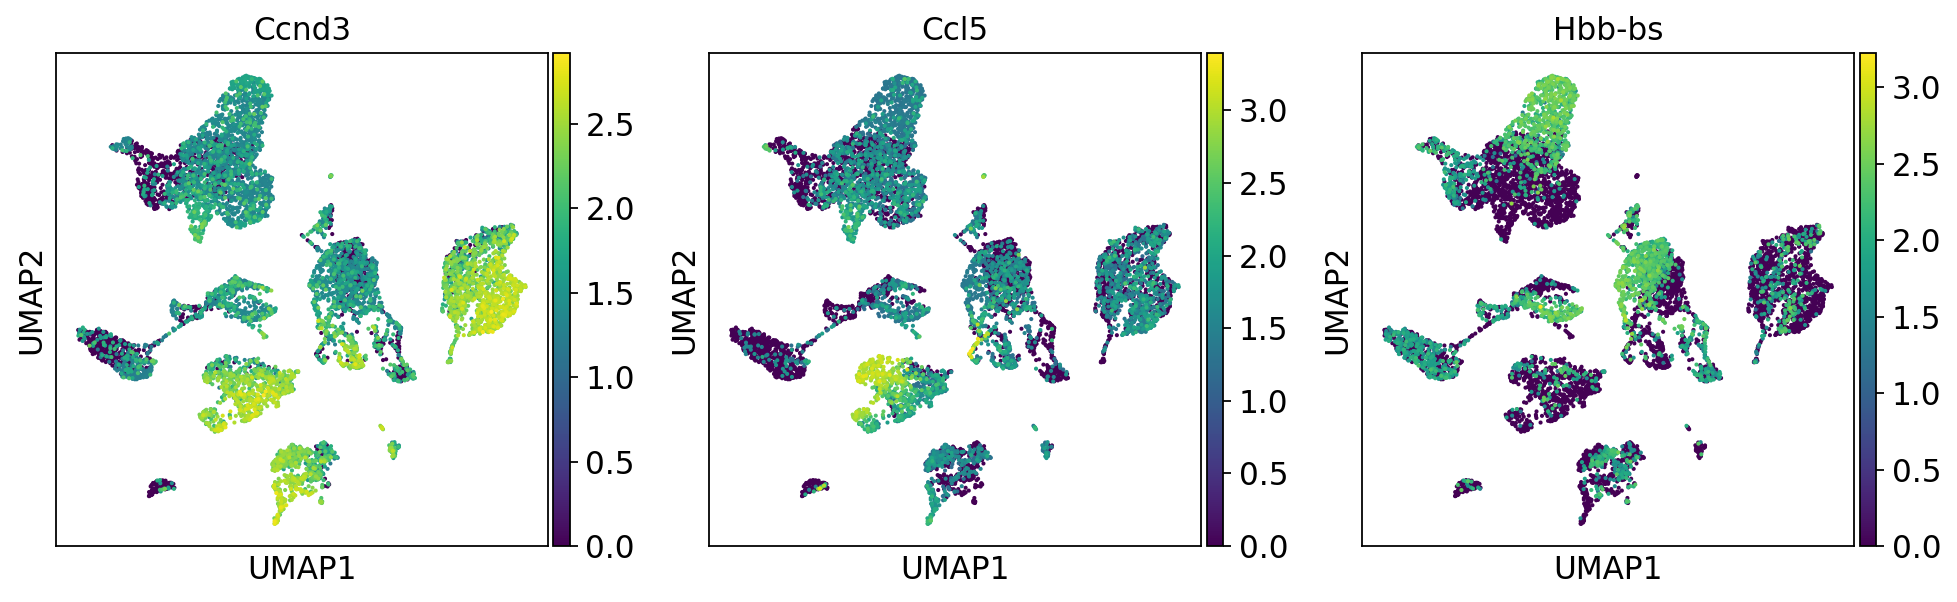

computing tSNE
    using 'X_pca' with n_pcs = 23
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:00:15)


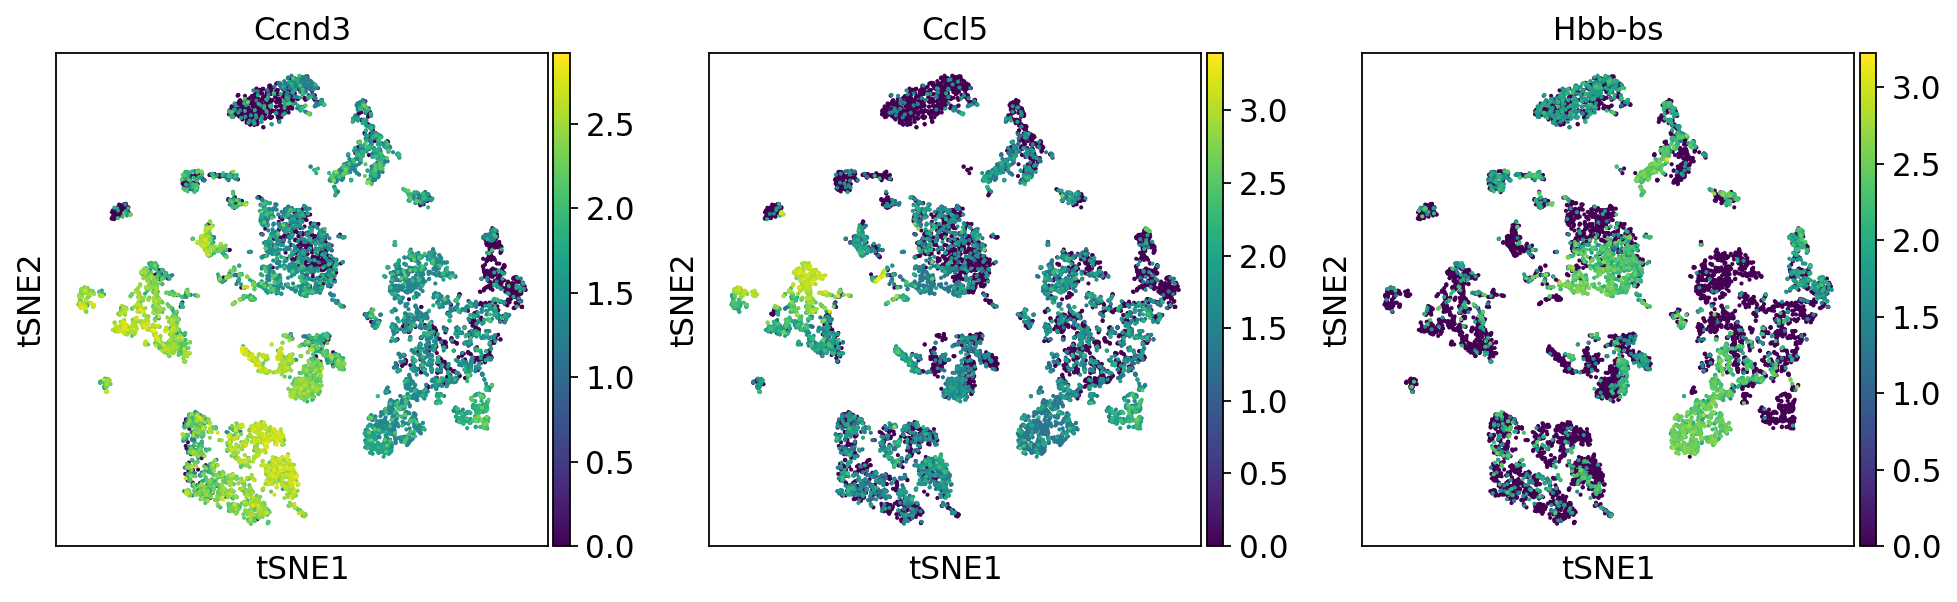

In [27]:
#visualize marker gene expression
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#visualize data with t-SNE
sc.tl.tsne(pcHVG_data, n_pcs = dim)
sc.pl.tsne(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:20)


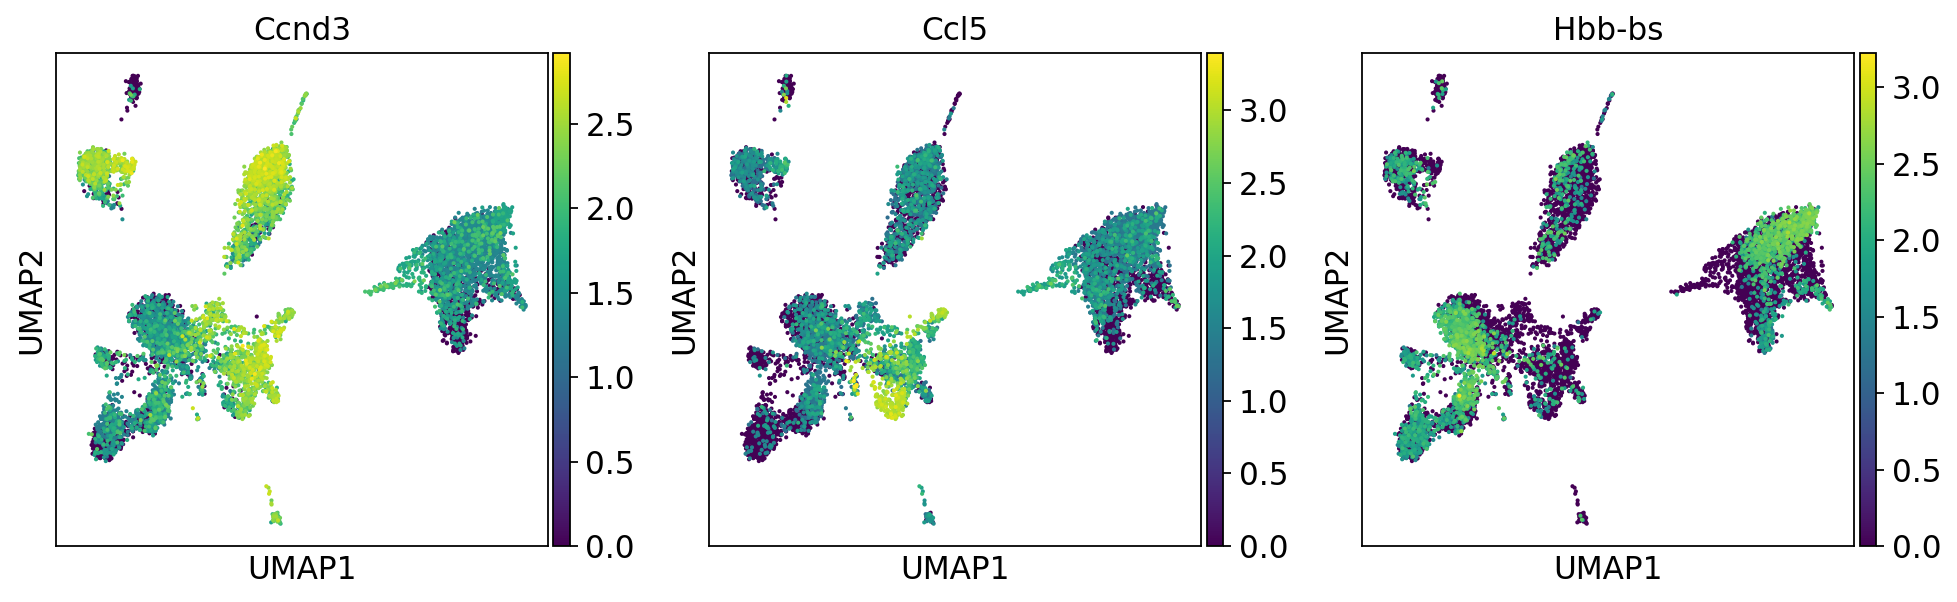

computing neighbors
    using 'X_pca' with n_pcs = 2
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:17)


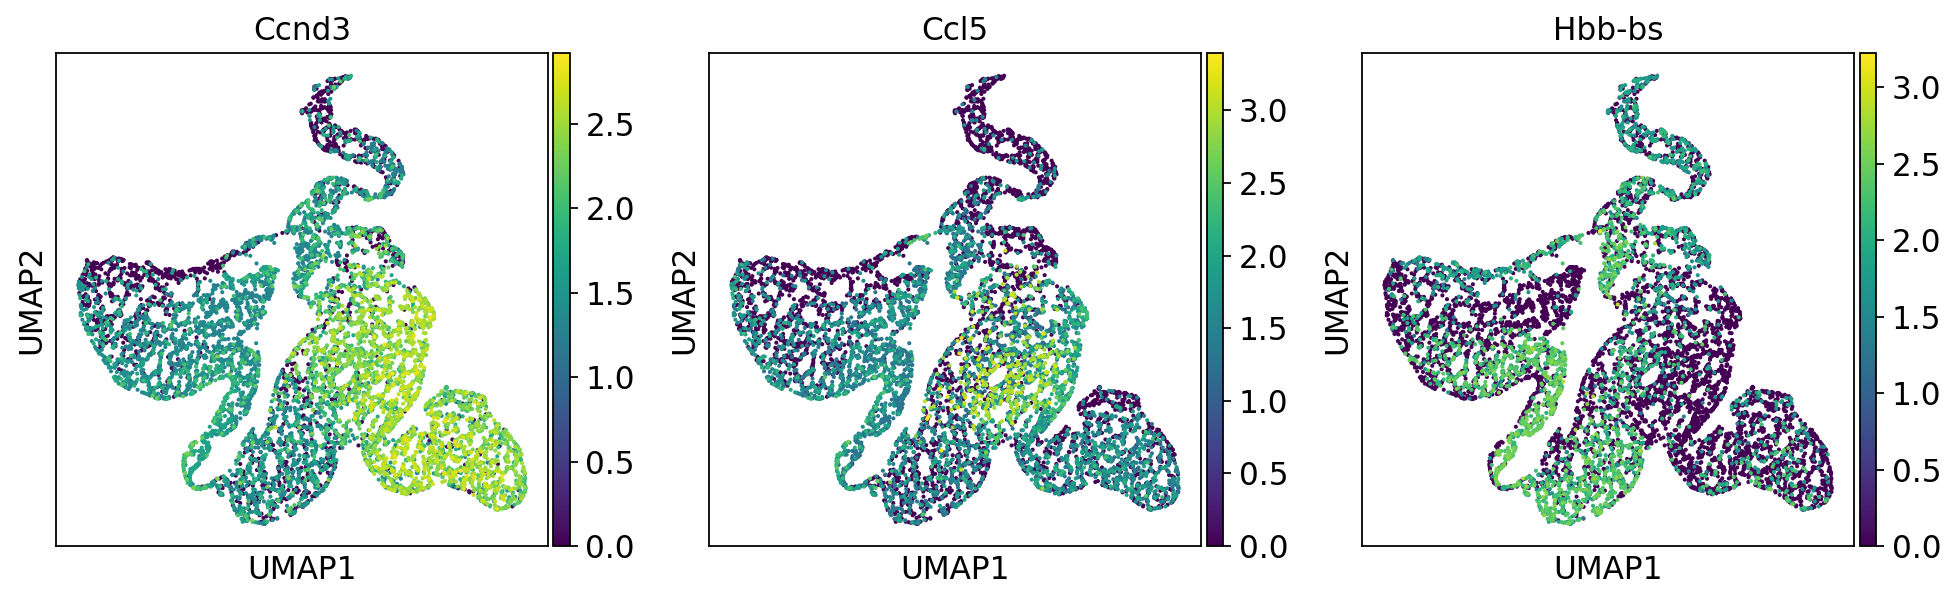

computing neighbors
    using 'X_pca' with n_pcs = 10
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:18)


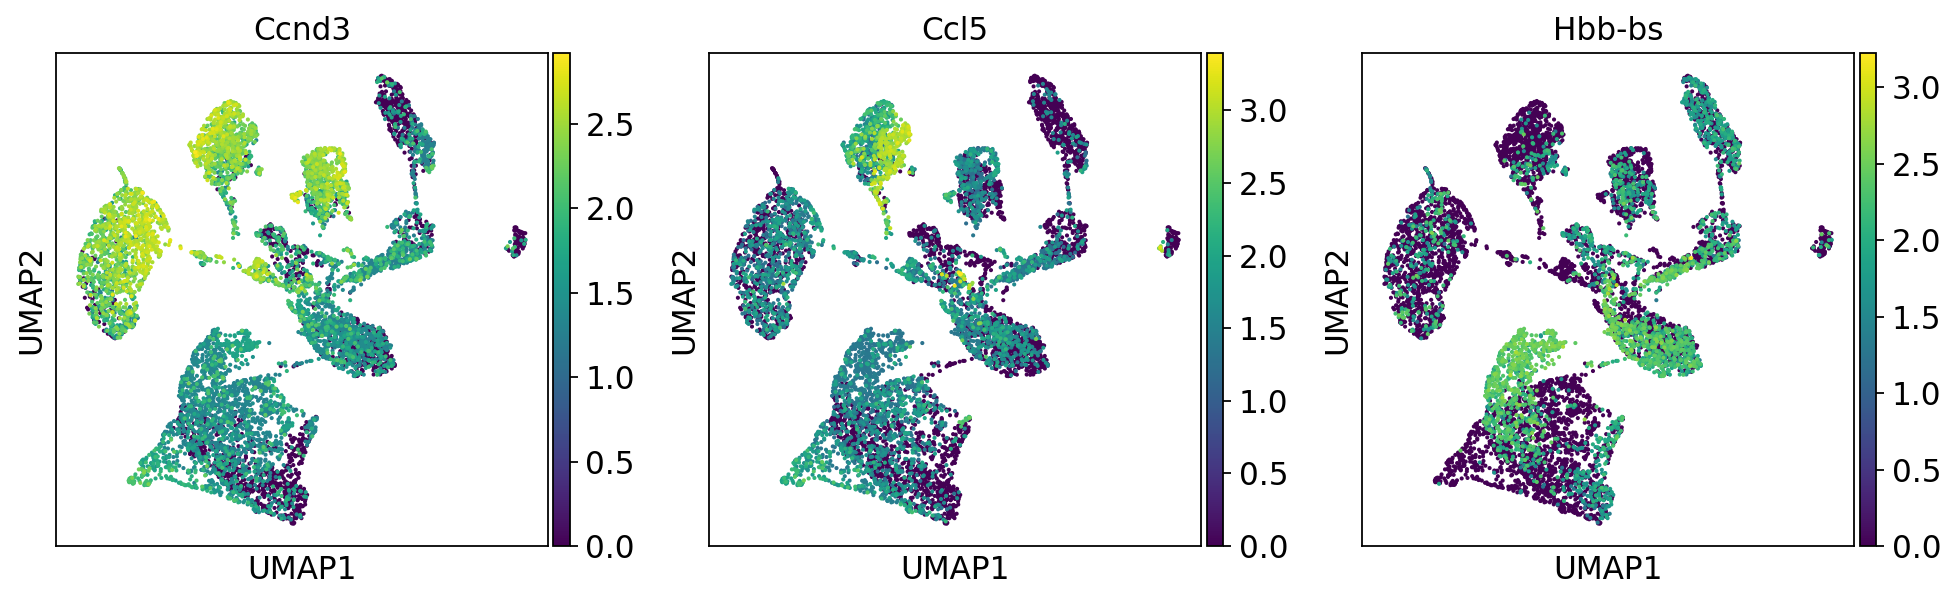

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:18)


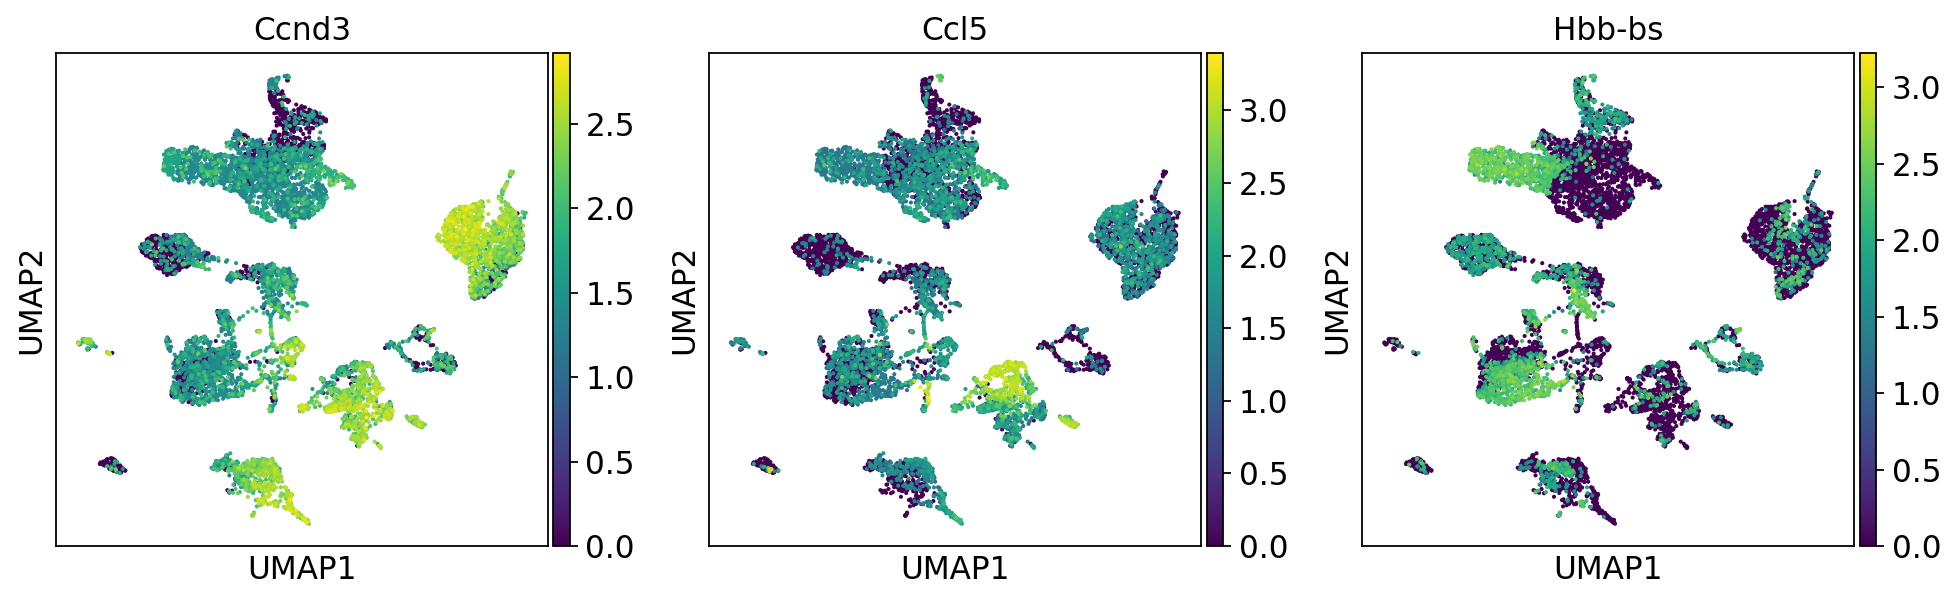

In [28]:
#computing the neighborhood graph on raw data, no PCs
sc.pp.neighbors(pcHVG_data, n_neighbors=10, n_pcs=0)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#how will the umap change if we use different numbers of PCs?

#computing the neighborhood graph, 2 PCs
sc.pp.neighbors(pcHVG_data, n_neighbors=10, n_pcs=2)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#computing the neighborhood graph, 10 PCs
sc.pp.neighbors(pcHVG_data, n_neighbors=10, n_pcs=10)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#computing the neighborhood graph, 50 PCs
sc.pp.neighbors(pcHVG_data, n_neighbors=10, n_pcs=50)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:20:40)


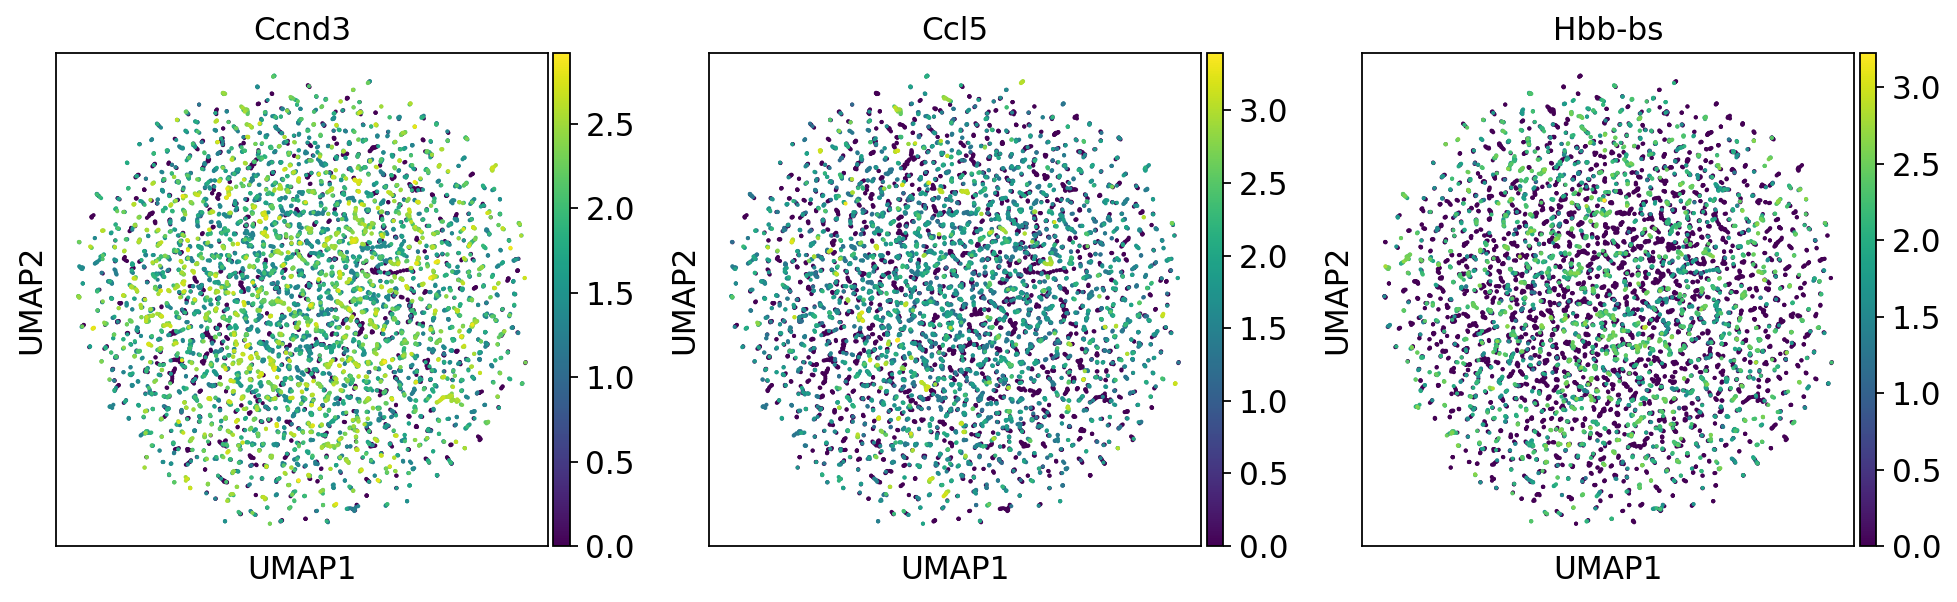

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:27)


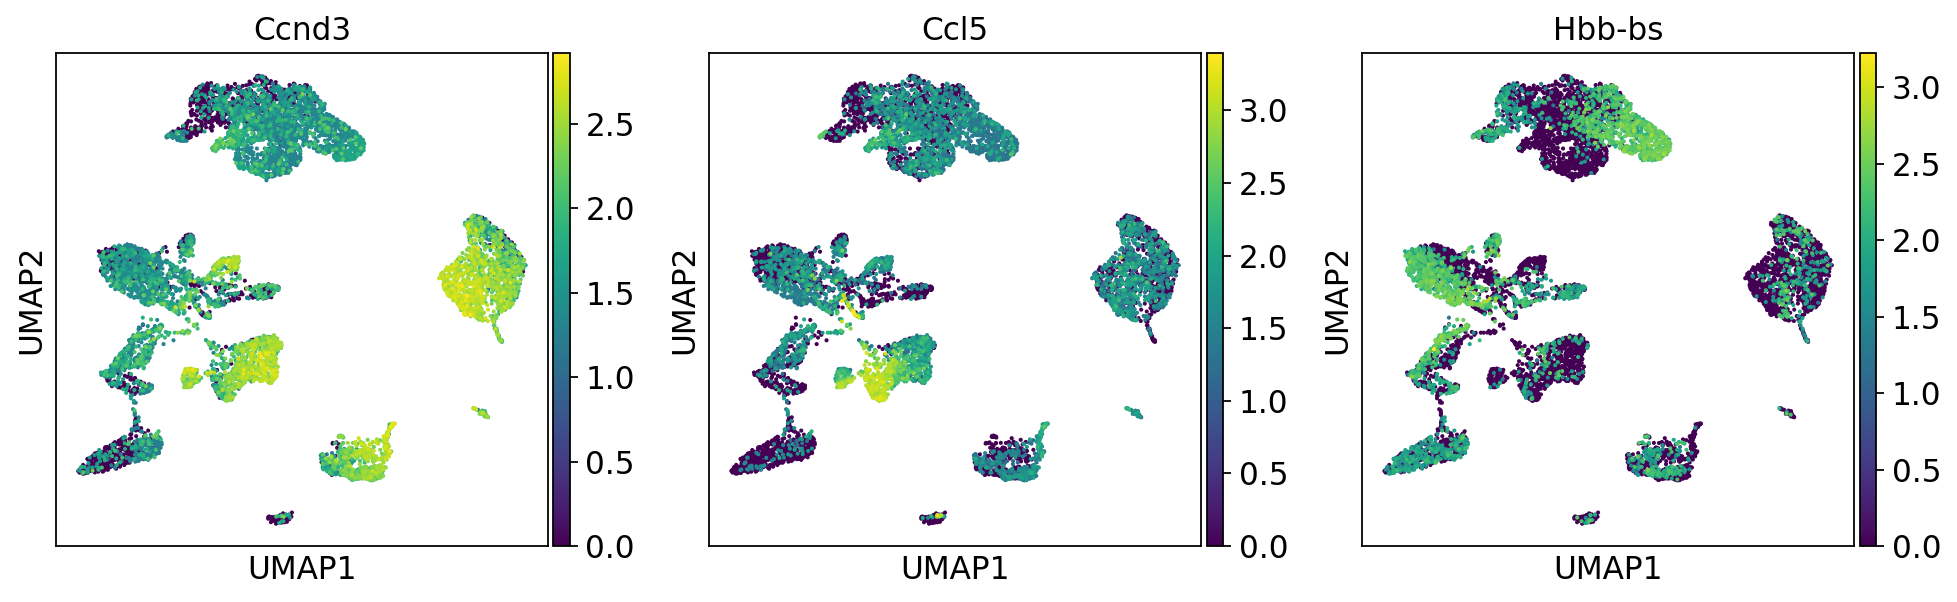

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:39)


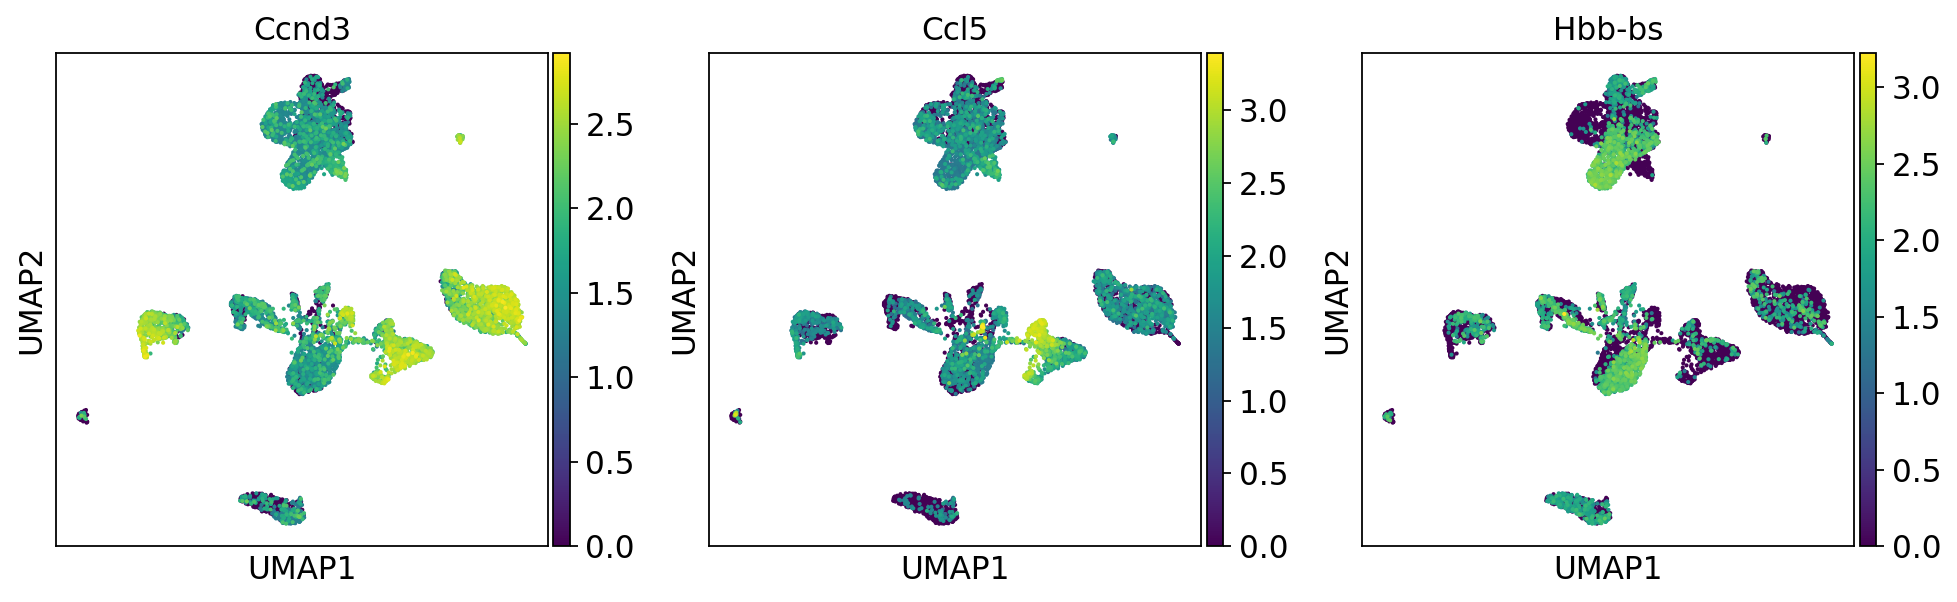

In [29]:
#2 neighbors
sc.pp.neighbors(pcHVG_data, n_neighbors=2, n_pcs=20)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#30 neighbors
sc.pp.neighbors(pcHVG_data, n_neighbors=30, n_pcs=20)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])

#100 neighbors
sc.pp.neighbors(pcHVG_data, n_neighbors=100, n_pcs=20)
sc.tl.umap(pcHVG_data)
sc.pl.umap(pcHVG_data, color=['Ccnd3', 'Ccl5', 'Hbb-bs'])